In [3]:
import os
import xml.etree.ElementTree as ET
from pathlib import Path
from collections import Counter, defaultdict
import yaml
from PIL import Image
import matplotlib.pyplot as plt
import shutil, random
import cv2
from ultralytics import YOLO

In [6]:
src = "./data/ArmaCV_dataset"
dst = "./data/ArmaCV_dataset_yolo26"

images_src = os.path.join(src, "images")
labels_src = os.path.join(src, "labels")

images_dst = os.path.join(dst, "images")
labels_dst = os.path.join(dst, "labels")

os.makedirs(images_dst, exist_ok=True)
os.makedirs(labels_dst, exist_ok=True)

classes = set()

for f in os.listdir(labels_src):
    if f.endswith(".xml"):
        tree = ET.parse(os.path.join(labels_src, f))
        root = tree.getroot()
        for obj in root.findall("object"):
            classes.add(obj.find("name").text)

classes = sorted(list(classes))
class_map = {c:i for i,c in enumerate(classes)}

for f in os.listdir(labels_src):
    if not f.endswith(".xml"):
        continue

    tree = ET.parse(os.path.join(labels_src, f))
    root = tree.getroot()

    w = int(root.find("size/width").text)
    h = int(root.find("size/height").text)

    yolo_lines = []

    for obj in root.findall("object"):
        cls = obj.find("name").text
        cid = class_map[cls]

        box = obj.find("bndbox")
        xmin = float(box.find("xmin").text)
        ymin = float(box.find("ymin").text)
        xmax = float(box.find("xmax").text)
        ymax = float(box.find("ymax").text)

        x = ((xmin + xmax) / 2) / w
        y = ((ymin + ymax) / 2) / h
        bw = (xmax - xmin) / w
        bh = (ymax - ymin) / h

        yolo_lines.append(f"{cid} {x} {y} {bw} {bh}")

    txt_name = Path(f).stem + ".txt"
    with open(os.path.join(labels_dst, txt_name), "w") as ftxt:
        ftxt.write("\n".join(yolo_lines))

In [11]:
ds1_yaml = Path("./data/ARMA-3.v8i.yolo26/data.yaml")   # first dataset
ds2_root = Path("./data/ArmaCV_dataset_yolo26")         # second dataset (images/, labels/)


def load_yaml_classes(yaml_path):
    with open(yaml_path, "r", encoding="utf-8") as f:
        data = yaml.safe_load(f)
    names = data["names"]
    if isinstance(names, dict):
        names = [names[k] for k in sorted(names.keys(), key=int)]
    return names

def yolo_label_classes(label_file):
    classes = []
    with open(label_file, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            cls_id = int(line.split()[0])
            classes.append(cls_id)
    return classes

def get_image_size(img_path):
    try:
        with Image.open(img_path) as im:
            return im.size  # (width, height)
    except:
        return None

def collect_yolo_dataset(images_dirs, labels_dirs, class_names, title="Dataset"):
    image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    images = []
    for d in images_dirs:
        d = Path(d)
        if d.exists():
            images.extend([p for p in d.rglob("*") if p.suffix.lower() in image_exts])

    labels = []
    for d in labels_dirs:
        d = Path(d)
        if d.exists():
            labels.extend(list(d.rglob("*.txt")))

    class_counter = Counter()
    image_class_counter = Counter()
    sizes = []
    seen_images_per_class = defaultdict(set)

    # map image stem -> path
    image_map = {p.stem: p for p in images}

    for lp in labels:
        cls_ids = yolo_label_classes(lp)
        if not cls_ids:
            continue

        # count objects
        class_counter.update(cls_ids)

        # count images per class
        unique_cls = set(cls_ids)
        for c in unique_cls:
            image_class_counter[c] += 1

        # image size
        img_path = image_map.get(lp.stem)
        if img_path:
            sz = get_image_size(img_path)
            if sz:
                sizes.append(sz)

    # report
    print(f"\n===== {title} =====")
    print(f"Number of images: {len(images)}")
    print(f"Number of label files: {len(labels)}")
    print(f"Classes ({len(class_names)}): {class_names}")

    if sizes:
        widths = [s[0] for s in sizes]
        heights = [s[1] for s in sizes]
        unique_sizes = Counter(sizes)

        print(f"Min image size: {min(widths)} x {min(heights)}")
        print(f"Max image size: {max(widths)} x {max(heights)}")
        print(f"Most common sizes: {unique_sizes.most_common(10)}")
    else:
        print("No image sizes could be read.")

    print("\nObject count per class:")
    for i, name in enumerate(class_names):
        print(f"  {i} - {name}: {class_counter[i]}")

    print("\nImage count per class:")
    for i, name in enumerate(class_names):
        print(f"  {i} - {name}: {image_class_counter[i]}")

    # plot = number of images containing each class
    x = list(range(len(class_names)))
    y = [image_class_counter[i] for i in x]

    plt.figure(figsize=(10, 5))
    plt.bar(x, y)
    plt.xticks(x, class_names, rotation=45, ha="right")
    plt.ylabel("Number of images")
    plt.title(f"{title} - Images per class")
    plt.tight_layout()
    plt.show()


===== Dataset 1 (ARMA-3 combined train+valid+test) =====
Number of images: 583
Number of label files: 583
Classes (5): ['Anti-air Defence', 'Battle-Tank', 'Logistics-Vehicle', 'M2A4-Slammer', 'Mobile-Radar']
Min image size: 1169 x 658
Max image size: 1169 x 658
Most common sizes: [((1169, 658), 583)]

Object count per class:
  0 - Anti-air Defence: 348
  1 - Battle-Tank: 298
  2 - Logistics-Vehicle: 322
  3 - M2A4-Slammer: 330
  4 - Mobile-Radar: 231

Image count per class:
  0 - Anti-air Defence: 158
  1 - Battle-Tank: 158
  2 - Logistics-Vehicle: 146
  3 - M2A4-Slammer: 149
  4 - Mobile-Radar: 148


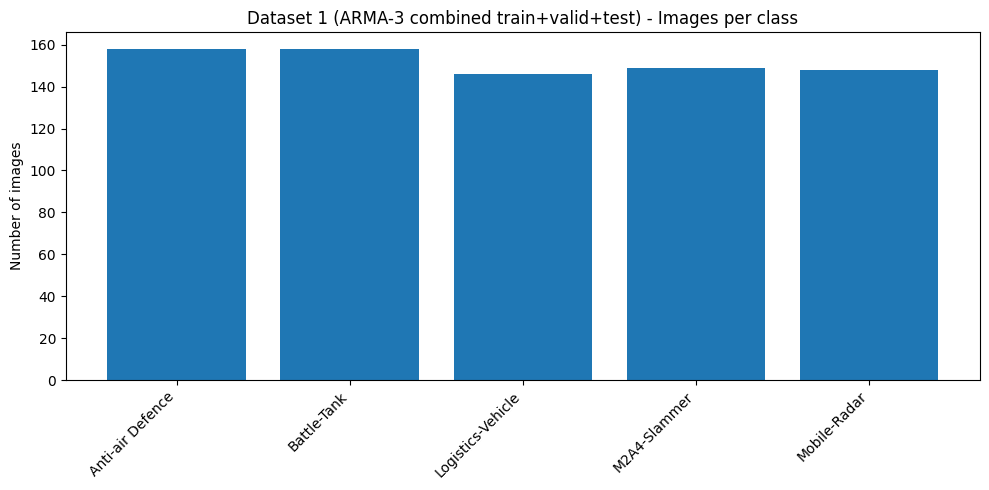


===== Dataset 2 (ArmaCV_dataset_yolo26) =====
Number of images: 363
Number of label files: 363
Classes (3): {'marid': 0, 'varsuk': 1, 'zamak': 2}
Min image size: 1712 x 1202
Max image size: 1795 x 1332
Most common sizes: [((1762, 1262), 4), ((1762, 1257), 3), ((1751, 1257), 3), ((1752, 1262), 3), ((1760, 1257), 3), ((1767, 1287), 3), ((1765, 1280), 3), ((1757, 1258), 3), ((1771, 1252), 2), ((1751, 1258), 2)]

Object count per class:
  0 - marid: 180
  1 - varsuk: 157
  2 - zamak: 159

Image count per class:
  0 - marid: 180
  1 - varsuk: 157
  2 - zamak: 159


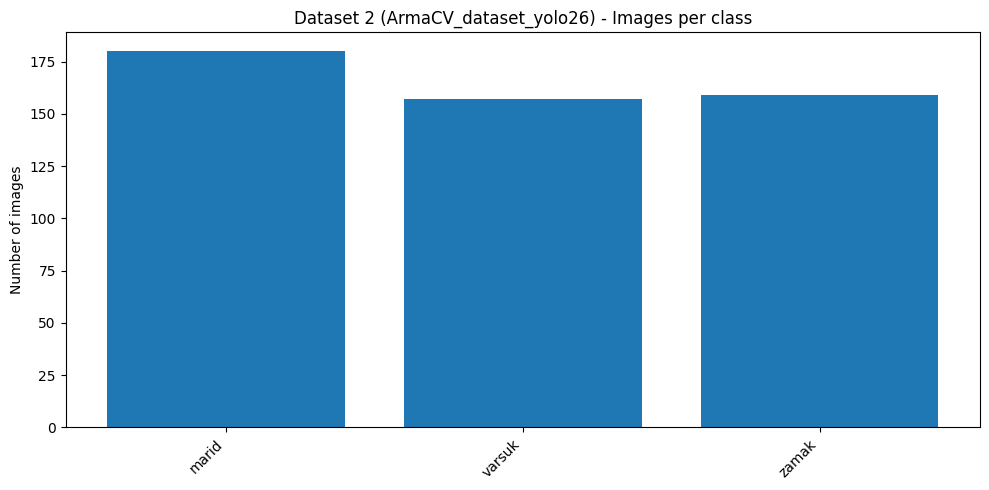

In [14]:
ds1_classes = load_yaml_classes(ds1_yaml)

ds1_base = ds1_yaml.parent
collect_yolo_dataset(
    images_dirs=[
        ds1_base / "train" / "images",
        ds1_base / "valid" / "images",
        ds1_base / "test" / "images",
    ],
    labels_dirs=[
        ds1_base / "train" / "labels",
        ds1_base / "valid" / "labels",
        ds1_base / "test" / "labels",
    ],
    class_names=ds1_classes,
    title="Dataset 1 (ARMA-3 combined train+valid+test)"
)


collect_yolo_dataset(
    images_dirs=[ds2_root / "images"],
    labels_dirs=[ds2_root / "labels"],
    class_names=class_map,
    title="Dataset 2 (ArmaCV_dataset_yolo26)"
)

In [ ]:
def merge_to_single_asset(datasets, output_dir):
    output_dir = Path(output_dir)
    img_out = output_dir / "images"
    lbl_out = output_dir / "labels"

    img_out.mkdir(parents=True, exist_ok=True)
    lbl_out.mkdir(parents=True, exist_ok=True)

    image_ext = {".jpg",".jpeg",".png",".bmp",".webp"}

    for ds in datasets:
        ds = Path(ds)
        imgs = ds / "images"
        lbls = ds / "labels"

        for img in imgs.iterdir():
            if img.suffix.lower() not in image_ext:
                continue

            new_name = f"{ds.name}_{img.name}"
            shutil.copy(img, img_out / new_name)

            label_path = lbls / (img.stem + ".txt")
            out_label = lbl_out / (Path(new_name).stem + ".txt")

            if label_path.exists():
                lines = []
                with open(label_path) as f:
                    for line in f:
                        parts = line.strip().split()
                        if len(parts) >= 5:
                            x,y,w,h = parts[1:5]
                            lines.append(f"0 {x} {y} {w} {h}")   # class -> asset (0)

                with open(out_label,"w") as f:
                    f.write("\n".join(lines))
            else:
                open(out_label,"w").close()

    print("done")



merge_to_single_asset(
    [
        "./data/ARMA-3.v8i.yolo26",
        "./data/ArmaCV_dataset_yolo26"
    ],
    "./data/combined_asset_dataset"
)

done


In [1]:
def merge_to_vehicle_groups(datasets, output_dir):
    """
    Merge datasets and map classes into 3 groups:
    0 = tracked_armored
    1 = wheeled_vehicle
    2 = support_system
    """

    class_map = {
        "Battle-Tank":0,
        "M2A4-Slammer":0,
        "varsuk":0,

        "Logistics-Vehicle":1,
        "marid":1,
        "zamak":1,

        "Anti-air Defence":2,
        "Mobile-Radar":2
    }

    output_dir = Path(output_dir)
    img_out = output_dir / "images"
    lbl_out = output_dir / "labels"

    img_out.mkdir(parents=True, exist_ok=True)
    lbl_out.mkdir(parents=True, exist_ok=True)

    image_ext = {".jpg",".jpeg",".png",".bmp",".webp"}

    for ds in datasets:
        ds = Path(ds)
        imgs = ds / "images"
        lbls = ds / "labels"

        for img in imgs.iterdir():
            if img.suffix.lower() not in image_ext:
                continue

            new_name = f"{ds.name}_{img.name}"
            shutil.copy(img, img_out / new_name)

            label_path = lbls / (img.stem + ".txt")
            out_label = lbl_out / (Path(new_name).stem + ".txt")

            if label_path.exists():
                lines = []
                with open(label_path) as f:
                    for line in f:
                        parts = line.strip().split()
                        if len(parts) >= 5:
                            cls = int(parts[0])
                            x,y,w,h = parts[1:5]

                            names = [
                                "Anti-air Defence",
                                "Battle-Tank",
                                "Logistics-Vehicle",
                                "M2A4-Slammer",
                                "Mobile-Radar",
                                "marid",
                                "varsuk",
                                "zamak"
                            ]

                            new_cls = class_map.get(names[cls])
                            if new_cls is not None:
                                lines.append(f"{new_cls} {x} {y} {w} {h}")

                with open(out_label,"w") as f:
                    f.write("\n".join(lines))
            else:
                open(out_label,"w").close()

    print("done")

In [5]:
from src.merge_datasets import DatasetMerger

class_mapping = {
    "tracked_armored": ["Battle-Tank", "M2A4-Slammer", "varsuk"],
    "wheeled_vehicle": ["Logistics-Vehicle", "marid", "zamak"],
    "support_system": ["Anti-air Defence", "Mobile-Radar"],
}

merger = DatasetMerger(
    dataset_paths=[
        "./data/ARMA-3.v8i.yolo26",
        "./data/ArmaCV_dataset_yolo26",
    ],
    output_dir="./data/combined_vehicle_groups",
    class_mapping=class_mapping,
    split=True,
    split_ratio=(0.8, 0.1, 0.1),
    seed=42,
)

merger.run()

Done. Output saved to: data/combined_vehicle_groups
Classes: ['tracked_armored', 'wheeled_vehicle', 'support_system']
Total images: 946
Train: 756
Val:   94
Test:  96


In [4]:
merge_to_vehicle_groups(
    [
        "./data/ARMA-3.v8i.yolo26",
        "./data/ArmaCV_dataset_yolo26"
    ],
    "./data/combined_vehicle_groups"
)

done


In [19]:
def split_yolo_dataset(src_dir, out_dir, train_ratio=0.9):
    src_dir = Path(src_dir)
    out_dir = Path(out_dir)

    img_src = src_dir / "images"
    lbl_src = src_dir / "labels"

    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    images = [p for p in img_src.iterdir() if p.suffix.lower() in exts]
    random.shuffle(images)

    n_train = int(len(images) * train_ratio)
    train_imgs = images[:n_train]
    valid_imgs = images[n_train:]

    for split, files in [("train", train_imgs), ("valid", valid_imgs)]:
        (out_dir / split / "images").mkdir(parents=True, exist_ok=True)
        (out_dir / split / "labels").mkdir(parents=True, exist_ok=True)

        for img in files:
            shutil.copy(img, out_dir / split / "images" / img.name)
            lbl = lbl_src / f"{img.stem}.txt"
            if lbl.exists():
                shutil.copy(lbl, out_dir / split / "labels" / lbl.name)

split_yolo_dataset("./data/combined_asset_dataset", "./data/combined_asset_dataset_split", train_ratio=0.85)

In [32]:
model = YOLO("yolo26l.pt")

In [33]:
model.train(
    data="./Dataset/data.yaml",
    epochs=20,
    imgsz=640,
    batch=8,
    device=0,
    workers=0,
    project="runs_yolo26",
    name="arma_asset"
)

Ultralytics 8.4.21 🚀 Python-3.10.19 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./Dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=arma_asset3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x700bcc265e70>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [2]:
def run_yolo_on_video(model_path, video_path, output_path, conf=0.25):
    model = YOLO(model_path)

    results = model.predict(
        source=video_path,
        conf=conf,
        save=False,
        stream=True
    )

    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()

    Path(output_path).parent.mkdir(parents=True, exist_ok=True)
    writer = cv2.VideoWriter(
        output_path,
        cv2.VideoWriter_fourcc(*"mp4v"),
        fps,
        (w, h)
    )

    for r in results:
        frame = r.plot()   # draws boxes + labels
        writer.write(frame)

    writer.release()
    print(f"Saved to: {output_path}")

In [4]:
run_yolo_on_video(
    model_path="./runs/detect/runs_yolo26/arma_asset3/weights/best.pt",
    video_path="sample.mp4",
    output_path="sample_labeled.mp4",
    conf=0.55
)


video 1/1 (frame 1/6612) /mnt/e/Desk/SIB/sample.mp4: 384x640 (no detections), 14.8ms
video 1/1 (frame 2/6612) /mnt/e/Desk/SIB/sample.mp4: 384x640 (no detections), 12.8ms
video 1/1 (frame 3/6612) /mnt/e/Desk/SIB/sample.mp4: 384x640 (no detections), 12.7ms
video 1/1 (frame 4/6612) /mnt/e/Desk/SIB/sample.mp4: 384x640 (no detections), 14.3ms
video 1/1 (frame 5/6612) /mnt/e/Desk/SIB/sample.mp4: 384x640 (no detections), 12.9ms
video 1/1 (frame 6/6612) /mnt/e/Desk/SIB/sample.mp4: 384x640 (no detections), 14.3ms
video 1/1 (frame 7/6612) /mnt/e/Desk/SIB/sample.mp4: 384x640 (no detections), 12.6ms
video 1/1 (frame 8/6612) /mnt/e/Desk/SIB/sample.mp4: 384x640 (no detections), 13.6ms
video 1/1 (frame 9/6612) /mnt/e/Desk/SIB/sample.mp4: 384x640 (no detections), 12.9ms
video 1/1 (frame 10/6612) /mnt/e/Desk/SIB/sample.mp4: 384x640 (no detections), 12.6ms
video 1/1 (frame 11/6612) /mnt/e/Desk/SIB/sample.mp4: 384x640 (no detections), 15.6ms
video 1/1 (frame 12/6612) /mnt/e/Desk/SIB/sample.mp4: 384x640 